In [1]:
import numpy as np
import pandas as pd
from reggression import Reggression
from eggp import EGGP
import matplotlib.pyplot as plt

In [2]:
def texfmt(x):
    return x

def thetafmt(x):
    return list(map(lambda y: round(float(y),2), x.split(";")))

def parfmt(x):
    if x=="nan" or (isinstance(x, float) and np.isnan(x)):
        return x
    return list(map(lambda y: round(y, 2), eval(x)))
    
def lossfmt(x):
    return f'{x:.2e}'

lossCols = ['loss_train']
eggpfmt = {'Math': texfmt, 'theta': thetafmt} | { k : lossfmt for k in lossCols }

reggfmt = {'Latex': texfmt,	'Fitness': lossfmt,	'Parameters': parfmt, 'DL': lossfmt}

In [96]:
df = pd.read_csv("flow_stress_phip0.1.csv")

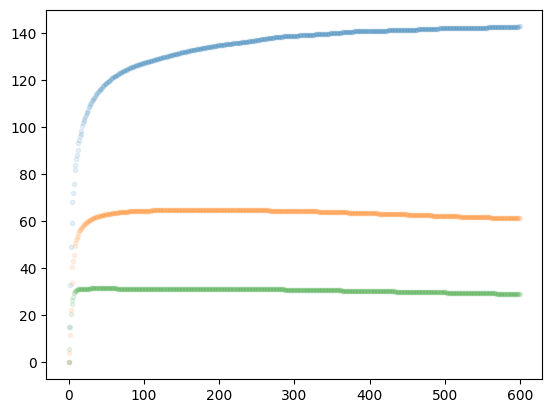

In [97]:
def plot_flow(f, df, useFun=False):
    rks = [200, 350, 500]#np.unique(df['T'].values)
    for rk in rks:
        df_k = df[df['T'] == rk]
        plt.plot(df_k["φ"], df_k["target"], '.', alpha=0.1)
        if useFun:
            x = np.array([[rk, xi] for xi in np.arange(0, 600, 5)])
            yhat = np.clip(f(x), 0, 200)
            plt.plot(x[:,1], yhat, '-')
plot_flow(lambda x: x["target"], df)
plt.savefig("flow.svg")

In [118]:
df = pd.read_csv("nikuradse_1.csv")

In [131]:
def plot_niku(f, df, useFun=False):
    rks = [507, 60, 30.6] #np.unique(df.rk.values)
    for rk in rks:
        df_k = df[df["rk"] == rk]
        plt.plot(df_k["Re"], df_k["target"], '.')
        if useFun:
            x = np.array([[rk, xi] for xi in np.arange(4, 6, 0.0001)])
            yhat = f(x)
            plt.plot(x[:,1], yhat, '-')

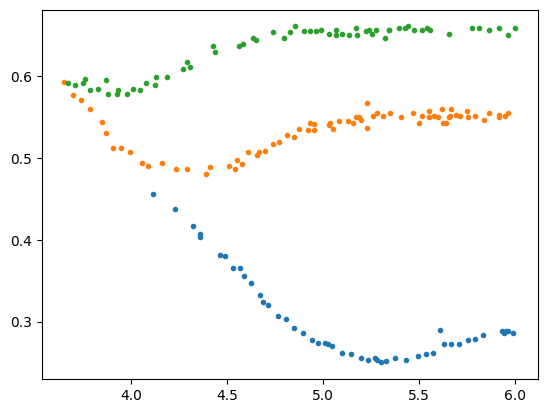

In [122]:
plot_niku(lambda x: x["target"], df)
plt.savefig("niku.svg")

In [141]:
df_sel = df[(df["Re"]>4.2) & (df["Re"]<5.5)]
reg = EGGP(gen=500, nPop=500, maxSize=50, nonterminals="add,sub,mul,div,log,power,sin,cos,abs,sqrt", simplify=True, optRepeat=2, optIter=20, folds=2, dumpTo="flow.egg")
reg.fit(df_sel[["rk", "Re"]], df_sel["target"])

,gen,500
,nPop,500
,maxSize,50
,nTournament,3
,pc,0.9
,pm,0.3
,nonterminals,"'add,sub,mul,div,log,power,sin,cos,abs,sqrt'"
,loss,'MSE'
,optIter,20
,optRepeat,2
,nParams,-1


In [142]:
reg.results[["Math", "size", "loss_train"]].style.format(eggpfmt)

,Math,size,loss_train
0,$$\theta_{0}$$,1,2.98e-02
1,$${\operatorname{rk}^{\theta_{0}}}$$,3,6.48e-03
2,$$\frac{\theta_{0}}{\operatorname{log}(\operatorname{rk})}$$,4,1.48e-03
3,$$\frac{\theta_{0}}{{\operatorname{rk}^{\theta_{1}}}}$$,5,9.40e-04
4,$$\left(\frac{\theta_{0}}{\left(\theta_{1} - \operatorname{sqrt}(\operatorname{rk})\right)} + \theta_{2}\right)$$,8,8.71e-04
5,$$\left(\operatorname{cos}(\operatorname{sqrt}(\left(\theta_{0} + \left |\operatorname{log}(\operatorname{rk})\right |\right))) + \theta_{1}\right)$$,9,8.74e-04
6,$$\left(\frac{\theta_{0}}{\left(\frac{\operatorname{rk}}{\left(\operatorname{Re} \cdot \theta_{1}\right)} + \theta_{2}\right)} + \theta_{3}\right)$$,11,8.30e-04
7,$$\left |\left(\frac{\theta_{0}}{\operatorname{log}(\operatorname{rk})} + \left(\left(\operatorname{rk} \cdot \theta_{1}\right) \cdot \operatorname{cos}(\operatorname{Re})\right)\right)\right |$$,12,8.09e-04
8,$$\left(\left(\frac{\left |\left(\operatorname{Re} \cdot \theta_{0}\right)\right |}{\operatorname{sqrt}(\operatorname{sqrt}(\operatorname{rk}))} + \theta_{1}\right) + \frac{\theta_{2}}{\operatorname{Re}}\right)$$,14,6.68e-04
9,$$\left |\left(\frac{\theta_{0}}{\operatorname{sqrt}(\operatorname{sqrt}(\frac{\operatorname{rk}}{\operatorname{Re}}))} + \left(\operatorname{cos}(\operatorname{Re}) \cdot \left(\operatorname{rk} \cdot \theta_{1}\right)\right)\right)\right |$$,15,5.70e-04


In [56]:
#print(reg.results[["Math", "size", "loss_train"]].to_markdown(index=False).replace("left |", "left (").replace("right |", "right )"))
print()

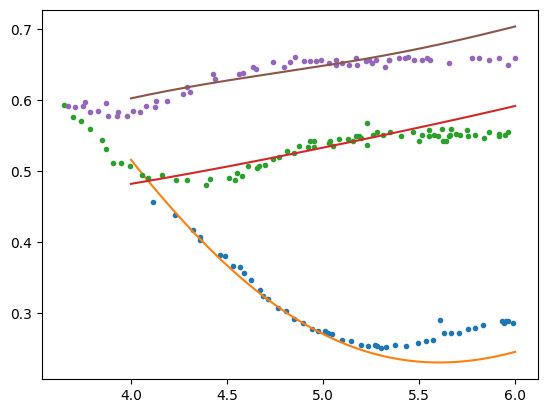

In [147]:
def model(ix):
    def f(x):
        t = np.array(list(map(float, reg.results.iloc[ix]["theta"].split(";"))))
        return eval(reg.results.iloc[ix]["Numpy"])
    return f
plot_niku(model(19), df, True)
#plt.savefig("flowSR.svg")

In [148]:
egg = Reggression(dataset="nikuradse_1.csv", loadFrom="flow.egg")

Calculating DL...
Welcome to r🥚ression


In [36]:
#print(egg.top(5)[["Latex", "Fitness", "Size"]].to_markdown(index=False).replace("\\begin{align}","$$").replace("\\end{align}","$$")) #.style.format(eggpfmt)
egg.top(5, filters=["size <=30"])[["Latex", "Fitness", "Size"]].style.format(eggpfmt)

,Latex,Fitness,Size
0,\begin{align}\left(\left(\frac{\operatorname{log}(\left(\left(\left(T + \theta_{0}\right) \cdot \left(\left(\left(Φ \cdot T\right) - T\right) \cdot Φ\right)\right) + \operatorname{log}(T)\right))}{T} \cdot \left(\theta_{1} - \left(T \cdot \operatorname{log}(\operatorname{log}(T))\right)\right)\right) + \left(Φ \cdot \theta_{2}\right)\right)\end{align},-4.598931,29
1,\begin{align}\left(\left(\frac{\operatorname{log}(\left(\left(\left(T + \theta_{0}\right) \cdot \left(\left(\left(Φ \cdot T\right) - T\right) \cdot Φ\right)\right) + \operatorname{log}(\operatorname{log}(T))\right))}{T} \cdot \left(\theta_{1} - \left(T \cdot \operatorname{log}(\operatorname{log}(T))\right)\right)\right) + \left(Φ \cdot \theta_{2}\right)\right)\end{align},-4.603409,30
2,\begin{align}\left(\left(\left(\frac{\operatorname{log}(\left(\left(T \cdot \left(\left(\left(Φ \cdot T\right) - T\right) \cdot Φ\right)\right) + \operatorname{log}(T)\right))}{T} \cdot \left(\theta_{0} - T\right)\right) + \left(\left(T \cdot \theta_{1}\right) + Φ\right)\right) + \left(Φ \cdot \theta_{2}\right)\right)\end{align},-5.489272,29
3,\begin{align}\left(\left(\frac{\operatorname{log}(\left(\left(\left(T + \theta_{0}\right) \cdot \left(\left(\left(Φ \cdot T\right) - T\right) \cdot Φ\right)\right) + \theta_{1}\right))}{T} \cdot \left(\theta_{2} - \left(T \cdot \operatorname{log}(\operatorname{log}(T))\right)\right)\right) + \left(Φ \cdot \theta_{3}\right)\right)\end{align},-5.543906,28
4,\begin{align}\left(\left(\frac{\operatorname{log}(\left(\left(\left(T + \theta_{0}\right) \cdot \left(\left(\left(Φ \cdot T\right) - T\right) \cdot Φ\right)\right) + \left(T + Φ\right)\right))}{T} \cdot \left(\theta_{1} - \left(T \cdot \operatorname{log}(\operatorname{log}(T))\right)\right)\right) + \left(Φ \cdot \theta_{2}\right)\right)\end{align},-5.713916,30


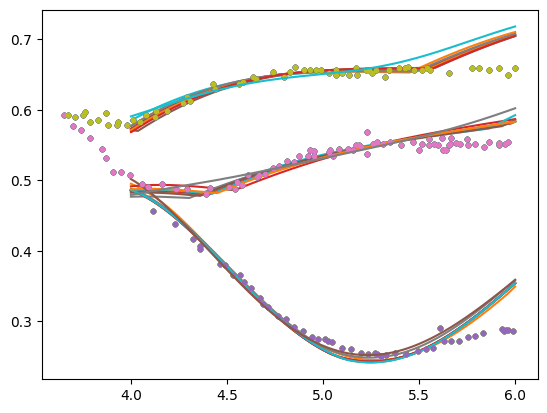

In [149]:
def model_top(res, n, df):
    for ix in range(n):
        def f(x):
            t = np.array(eval(res.iloc[ix]["Parameters"]))
            return eval(res.iloc[ix]["Numpy"])
        
        plot_niku(f, df, True)
        
#plot_niku(model(19), df, True)
#plt.savefig("nikuSR_tops.svg")
n=10
model_top(egg.top(n=n), n, df)

In [25]:
print(egg.top(3, filters=["size <=15"])[["Latex", "Fitness", "Size"]].to_markdown(index=False).replace("\\begin{align}","$$").replace("\\end{align}","$$"))

| Latex                                                                                                                                                                                               |   Fitness |   Size |
|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------:|-------:|
| $$\left(\left(\theta_{0} - \frac{\theta_{1}}{T}\right) + \left(\frac{Φ}{\left(T \cdot \left(Φ + \theta_{2}\right)\right)} \cdot \theta_{3}\right)\right)$$                      |  -15.0013 |     15 |
| $$\left(\theta_{0} + \left(\frac{\theta_{1}}{\left(\left(\operatorname{log}(\operatorname{log}(\left(T + \theta_{2}\right))) + Φ\right) \cdot T\right)} \cdot Φ\right)\right)$$ |  -15.089  |     15 |
| $$\left(\theta_{0} + \left(\frac{\theta_{1}}{\left(T \cdot \left(\theta_{2} + Φ\right)\right)} \cdot Φ\right)\right)$$                                    